Dataset Shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


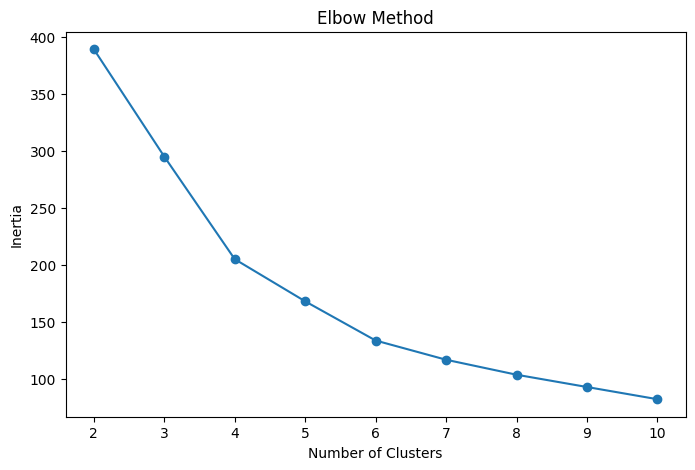

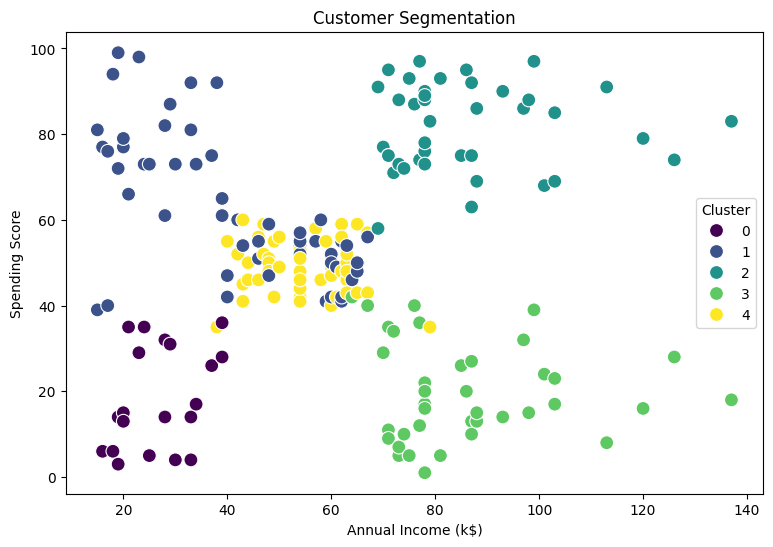


Cluster Profile:
         Customers  Average_Age  Average_Income  Average_Spending
Cluster                                                          
0               20        46.25           26.75             18.35
1               54        25.19           41.09             62.24
2               40        32.88           86.10             81.53
3               39        39.87           86.10             19.36
4               47        55.64           54.38             48.85

Silhouette Score: 0.4166

Files saved:
customer_segments.csv
cluster_report.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ==========================================
# 1. LOAD DATA
# ==========================================

df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# ==========================================
# 2. CLEAN DATA
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())

df = df.drop_duplicates()
df = df.dropna()


# ==========================================
# 3. SELECT FEATURES
# ==========================================

features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]


# ==========================================
# 4. SCALE FEATURES
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ==========================================
# 5. ELBOW METHOD
# ==========================================

inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


# ==========================================
# 6. K-MEANS
# ==========================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)


# ==========================================
# 7. VISUALIZE CLUSTERS
# ==========================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()


# ==========================================
# 8. CLUSTER PROFILE
# ==========================================

profile = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
)

print("\nCluster Profile:")
print(profile.round(2))


# ==========================================
# 9. SILHOUETTE SCORE
# ==========================================

score = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print("\nSilhouette Score:", round(score, 4))


# ==========================================
# 10. SAVE RESULTS
# ==========================================

df.to_csv(
    "customer_segments.csv",
    index=False
)

profile.to_csv(
    "cluster_report.csv"
)

print("\nFiles saved:")
print("customer_segments.csv")
print("cluster_report.csv")